# `hormone_cycler` healthy-cycle calibration and validation

This notebook distinguishes two kinds of evidence:

1. **Calibration-target reproduction:** simulated age-band means, within-person SDs,
   participant-level irregularity, cycle tails, phase lengths, and bleeding are
   compared with Li et al. (AWHS) and Bull et al.
2. **Held-out external cross-check:** 12-month participant summaries are compared with
   Cunningham et al.'s independent global Flo cohort, which was not used for fitting.
3. **Waveform validation:** Stricker et al.'s complete daily LH-aligned serum medians
   determine the luteal envelope. Anckaert et al.'s separate 85-woman serum cohort is
   an independent subphase amplitude/order check. Daily morphology checks require a
   broad postovulatory progesterone summit, correctly ordered rise/peak/withdrawal,
   a secondary luteal estradiol rise, and continuity across cycle boundaries.
4. **Long-follicular estradiol stress test:** Harlow et al.'s observed delayed-dominant-
   emergence and failed-dominant-wave geometries are shown without stretching one
   ordinary E2 curve across all extra follicular days. Mumford et al. provides an
   independent timing context: long-cycle E2 peaks were about three days later, not
   proportionally stretched over the entire long cycle.

The central waveform correction in v0.3.0 replaces sparse subphase control points
with the complete daily Stricker serum series, aligns that series to the simulator's
ovulation event, and adds independently checked morphology criteria. Long follicular
phases now preserve a terminal 14-day maturation interval and use delayed-emergence or
failed-wave E2 geometry rather than stretching an ordinary-cycle template.

The central cycle-variability correction introduced in v0.2.0 was estimand alignment:
AWHS classified a participant
as irregular when that person's *mean adjacent-cycle difference* was at least seven
days. The table footnote omits “absolute,” but the methods define adjacent-cycle
differences as absolute values; v0.2.0 follows that convention. The previous notebook
instead averaged pairwise threshold exceedances.

The baseline validation cohort is restricted to ages 18–54.9 because AWHS enrollment
required adulthood. The separate peri-menarche modifier scenario retains adolescent
ages and tests that distinct physiology explicitly.

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from hormone_cycler.literature import CITATIONS
from hormone_cycler.model import simulate_diary
from hormone_cycler.validation import run_population_validation
from render_healthy_cycle_examples_v12 import render as render_examples
from render_hormone_waveform_validation_v13 import render as render_waveform_figure
from render_hormone_validation_figure_v12 import render as render_validation_figure

REPORT_PATH = ROOT / "examples" / "reports" / "healthy_cycle_validation_v13.json"
KINETICS_FIGURE_PATH = ROOT / "examples" / "reports" / "hormone_kinetics_validation_v13.png"
VALIDATION_FIGURE_PATH = ROOT / "examples" / "reports" / "hormone_cycle_validation_v13.png"
EXAMPLE_PNG_PATH = ROOT / "examples" / "reports" / "healthy_cycle_example_traces_v13.png"
EXAMPLE_SVG_PATH = ROOT / "examples" / "reports" / "healthy_cycle_example_traces_v13.svg"
WAVEFORM_FIGURE_PATH = ROOT / "examples" / "reports" / "hormone_waveform_validation_v13.png"
WAVEFORM_SVG_PATH = ROOT / "examples" / "reports" / "hormone_waveform_validation_v13.svg"
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

## Cohort-size convergence

All runs use the same deterministic base seed but generate distinct patient seeds.
The baseline cohorts are ages 18–54.9, matching AWHS adult eligibility. The retained
16-diary hormone sample is balanced across the eight age bands (two per band) so the
kinetic checks are not restricted to participants younger than 20 years.

In [2]:
cohort_sizes = [500, 2_000, 10_000]
reports = {
    size: run_population_validation(
        num_patients=size,
        days=365,
        seed=7,
        include_subgroups=(size == 10_000),
        start_mode="random",
    )
    for size in cohort_sizes
}

convergence = pd.DataFrame(
    [
        {
            "patients": size,
            "overall_passed": report["baseline_passed"],
            "calibration_passed": report["calibration_passed"],
            "external_crosscheck_passed": report["external_crosscheck_passed"],
            "checks_passed": sum(metric["passed"] for metric in report["baseline_metrics"]),
            "checks_total": len(report["baseline_metrics"]),
            "hormone_diaries": report["hormone_smoke_sample"]["n_diaries"],
        }
        for size, report in reports.items()
    ]
)
display(convergence)
print("10,000-participant hormone sample by age band:")
display(pd.Series(reports[10_000]["hormone_smoke_sample"]["age_band_counts"], name="diaries").to_frame())

,patients,overall_passed,calibration_passed,external_crosscheck_passed,checks_passed,checks_total,hormone_diaries
0,500,False,False,False,74,81,16
1,2000,False,False,True,78,81,16
2,10000,True,True,True,81,81,16


10,000-participant hormone sample by age band:


,diaries
<20,2
20-24,2
25-29,2
30-34,2
35-39,2
40-44,2
45-49,2
50+,2


## Healthy-cycle calibration outcomes

The AWHS comparisons use equal participant weighting and at most the first 11 cycles,
matching the source cohort's median follow-up. Within-person SD is pooled after
subtracting each participant's mean. Irregularity is the proportion of participants
whose mean absolute adjacent-cycle difference is at least seven days.

In [3]:
full_report = reports[10_000]
calibration_cycle_metrics = pd.DataFrame(
    [
        metric for metric in full_report["calibration_metrics"]
        if metric["name"].startswith("cycle_")
    ]
)
display(calibration_cycle_metrics[["name", "observed", "expected", "lower_bound", "upper_bound", "passed"]])
assert calibration_cycle_metrics["passed"].all()

,name,observed,expected,lower_bound,upper_bound,passed
0,cycle_mean_<20,29.8490,29.8200,29.2700,30.3700,True
1,cycle_within_person_sd_<20,5.3540,5.3300,4.9800,5.6800,True
2,cycle_irregularity_<20,0.2040,0.2040,0.1690,0.2390,True
3,cycle_short_lt24_<20,0.0652,0.0771,0.0471,0.1071,True
4,cycle_long_gt38_<20,0.0637,0.0833,0.0533,0.1133,True
5,cycle_mean_20-24,29.5480,29.6200,29.0700,30.1700,True
6,cycle_within_person_sd_20-24,5.1510,5.0700,4.7200,5.4200,True
7,cycle_irregularity_20-24,0.2296,0.2090,0.1740,0.2440,True
8,cycle_short_lt24_20-24,0.0750,0.0722,0.0422,0.1022,True
9,cycle_long_gt38_20-24,0.0620,0.0688,0.0388,0.0988,True


## Held-out external cross-check

Cunningham et al. use different inclusion filters and average each user's ordinary
12-month sample SD, so these values are not expected to equal AWHS mixed-model residual
SDs. Agreement is strongest from ages 26–45. The simulator remains higher than Flo at
ages 51–55, while closely matching the larger AWHS residual SD; that conflict is retained
as a limitation rather than hidden by refitting to the held-out cohort.

In [4]:
external_metrics = pd.DataFrame(full_report["external_crosscheck_metrics"])
display(external_metrics[["name", "observed", "expected", "lower_bound", "upper_bound", "passed", "notes"]])
assert external_metrics["passed"].all()

,name,observed,expected,lower_bound,upper_bound,passed,notes
0,external_cunningham_mean_18-25,29.660,28.99,27.49,30.49,True,Mean participant cycle length over a 12-month-...
1,external_cunningham_mean_personal_sd_18-25,4.783,4.14,2.89,5.39,True,Mean participant-specific sample SD over a 12-...
2,external_cunningham_mean_26-30,29.239,28.76,27.26,30.26,True,Mean participant cycle length over a 12-month-...
3,external_cunningham_mean_personal_sd_26-30,4.194,3.95,2.70,5.20,True,Mean participant-specific sample SD over a 12-...
4,external_cunningham_mean_31-35,28.663,28.28,26.78,29.78,True,Mean participant cycle length over a 12-month-...
5,external_cunningham_mean_personal_sd_31-35,3.748,3.80,2.55,5.05,True,Mean participant-specific sample SD over a 12-...
6,external_cunningham_mean_36-40,28.108,27.68,26.18,29.18,True,Mean participant cycle length over a 12-month-...
7,external_cunningham_mean_personal_sd_36-40,3.001,3.72,2.47,4.97,True,Mean participant-specific sample SD over a 12-...
8,external_cunningham_mean_41-45,27.713,27.18,25.68,28.68,True,Mean participant cycle length over a 12-month-...
9,external_cunningham_mean_personal_sd_41-45,3.341,3.92,2.67,5.17,True,Mean participant-specific sample SD over a 12-...


## Hormone amplitude and daily-morphology checks

The amplitude rows compare simulated subphases with Anckaert et al., which was not used
to build the waveform. Broad windows are intentional because the cohorts and assays
differ. The daily rows then test the specific morphology that motivated this update:
P4 plateau width, rise and peak timing, withdrawal, the luteal E2 rebound, and boundary
continuity. This separates external amplitude evidence from internal shape checks.

In [5]:
hormone_metrics = pd.DataFrame(
    [
        metric
        for metric in full_report["baseline_metrics"]
        if metric["name"].startswith(("estradiol_", "progesterone_"))
    ]
)
display(
    hormone_metrics[
        ["name", "observed", "expected", "lower_bound", "upper_bound", "passed", "notes"]
    ]
)
assert hormone_metrics["passed"].all()

,name,observed,expected,lower_bound,upper_bound,passed,notes
0,estradiol_early_follicular,46.7900,34.051,13.620,62.994,True,Independent Anckaert serum-E2 subphase median;...
1,progesterone_early_follicular,0.3800,0.119,0.050,0.650,True,Independent Anckaert serum-P4 subphase median;...
2,estradiol_mid_follicular,80.9750,46.854,18.741,86.679,True,Independent Anckaert serum-E2 subphase median;...
3,progesterone_mid_follicular,0.1900,0.066,0.050,0.650,True,Independent Anckaert serum-P4 subphase median;...
4,estradiol_pre_ovulatory,181.1100,126.396,50.558,233.833,True,Independent Anckaert serum-E2 subphase median;...
5,progesterone_pre_ovulatory,0.2100,0.059,0.050,0.650,True,Independent Anckaert serum-P4 subphase median;...
6,estradiol_ovulation,94.4000,222.555,89.022,411.727,True,Independent Anckaert serum-E2 subphase median;...
7,progesterone_ovulation,1.4500,0.500,0.050,2.000,True,Independent Anckaert serum-P4 subphase median;...
8,estradiol_early_luteal,93.9100,106.238,42.495,196.540,True,Independent Anckaert serum-E2 subphase median;...
9,progesterone_early_luteal,7.7900,7.107,3.198,13.148,True,Independent Anckaert serum-P4 subphase median;...


## Direct visual and numerical kinetic check

The displayed interval contains one complete ovulatory cycle plus the first day of the
next cycle. Estradiol and progesterone have separate axes because their units and scales
are not commensurate. The dashed line is the next bleeding onset/cycle boundary.

,check,observed,criterion
0,Estradiol days at >=80% follicular maximum,3.000000,>=2 days
1,Luteal E2 peak / follicular E2 peak,0.619154,0.35-0.80
2,Progesterone days at >=75% maximum,8.000000,3-9 days
3,Progesterone peak offset from ovulation,8.000000,3-9 days
4,Progesterone 5 ng/mL rise offset,3.000000,1-4 days
5,Consecutive progesterone-decline transitions b...,5.000000,>=3
6,Final-cycle progesterone / cycle maximum,0.033546,<=0.20
7,Progesterone jump across cycle boundary (ng/mL),0.000000,<=1.0
8,Realized luteal length (days),16.000000,9-17


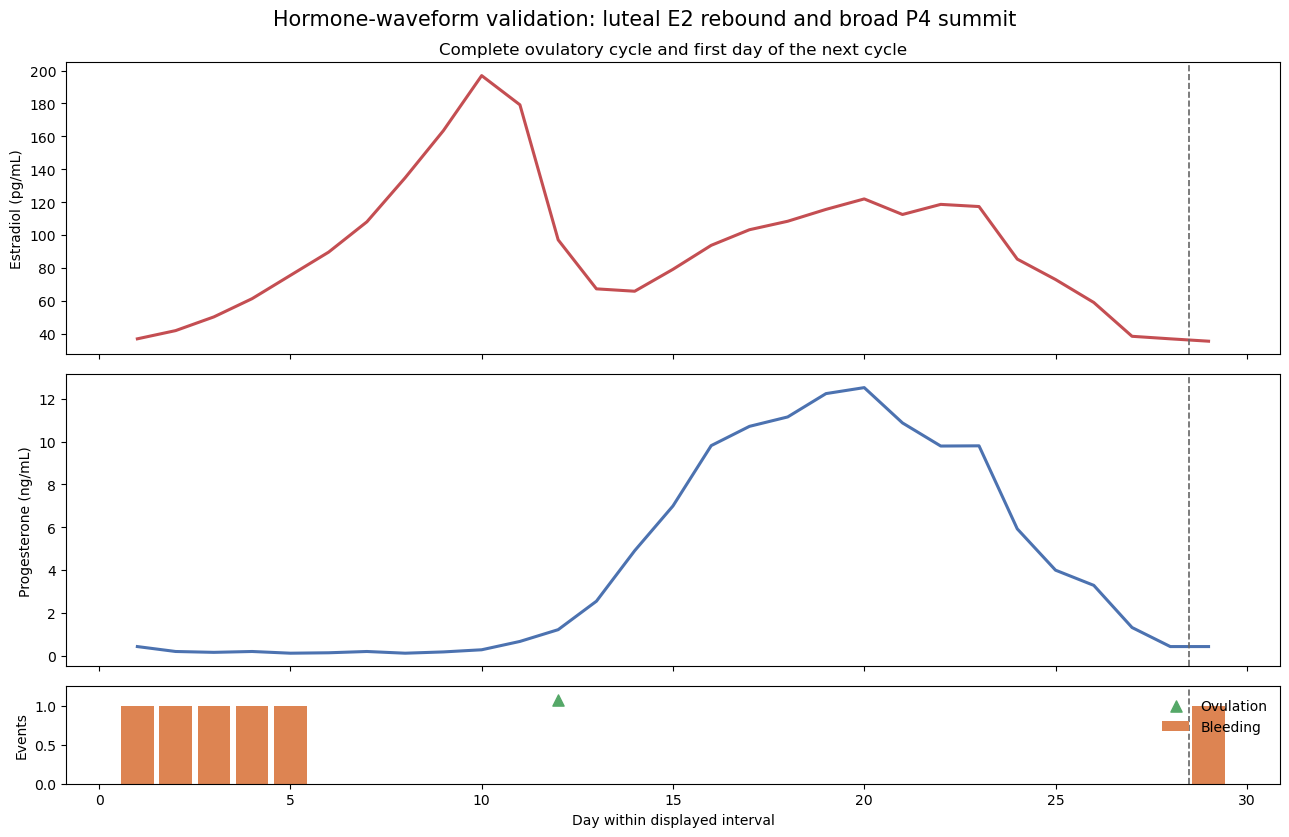

In [6]:
result = simulate_diary(
    days=140,
    age_years=31,
    seed=1,
    patient_id="kinetic-validation",
    start_mode="cycle_day_1",
)
complete_cycle = next(cycle for cycle in result.cycles if cycle.ovulatory)
cycle_rows = [row for row in result.diary if row.cycle_index == complete_cycle.cycle_index]
next_rows = [row for row in result.diary if row.cycle_index == complete_cycle.cycle_index + 1]
display_rows = cycle_rows + next_rows[:1]

e2 = [row.estradiol_pg_ml for row in cycle_rows[: complete_cycle.ovulation_day]]
p4 = [row.progesterone_ng_ml for row in cycle_rows]
peak_width = sum(value >= 0.80 * max(e2) for value in e2)
p4_peak = max(p4)
p4_peak_day = p4.index(p4_peak) + 1
p4_plateau_width = sum(value >= 0.75 * p4_peak for value in p4)
p4_rise_day = next(
    day
    for day, value in enumerate(p4, start=1)
    if day >= complete_cycle.ovulation_day and value >= 5.0
)
luteal_e2 = [row.estradiol_pg_ml for row in cycle_rows[complete_cycle.ovulation_day:]]
secondary_e2_ratio = max(luteal_e2) / max(e2)
withdrawal_transitions = 0
for earlier, later in zip(reversed(p4[:-1]), reversed(p4[1:])):
    if later < earlier:
        withdrawal_transitions += 1
    else:
        break
diagnostics = pd.DataFrame(
    [
        {"check": "Estradiol days at >=80% follicular maximum", "observed": peak_width, "criterion": ">=2 days"},
        {"check": "Luteal E2 peak / follicular E2 peak", "observed": secondary_e2_ratio, "criterion": "0.35-0.80"},
        {"check": "Progesterone days at >=75% maximum", "observed": p4_plateau_width, "criterion": "3-9 days"},
        {"check": "Progesterone peak offset from ovulation", "observed": p4_peak_day - complete_cycle.ovulation_day, "criterion": "3-9 days"},
        {"check": "Progesterone 5 ng/mL rise offset", "observed": p4_rise_day - complete_cycle.ovulation_day, "criterion": "1-4 days"},
        {"check": "Consecutive progesterone-decline transitions before bleeding", "observed": withdrawal_transitions, "criterion": ">=3"},
        {"check": "Final-cycle progesterone / cycle maximum", "observed": p4[-1] / max(p4), "criterion": "<=0.20"},
        {"check": "Progesterone jump across cycle boundary (ng/mL)", "observed": abs(next_rows[0].progesterone_ng_ml - p4[-1]), "criterion": "<=1.0"},
        {"check": "Realized luteal length (days)", "observed": complete_cycle.luteal_length, "criterion": "9-17"},
    ]
)
display(diagnostics)

x = list(range(1, len(display_rows) + 1))
boundary = len(cycle_rows) + 0.5
fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=True, gridspec_kw={"height_ratios": [3, 3, 1]})
axes[0].plot(x, [row.estradiol_pg_ml for row in display_rows], color="#C44E52", linewidth=2.2)
axes[0].set_ylabel("Estradiol (pg/mL)")
axes[0].set_title("Complete ovulatory cycle and first day of the next cycle")
axes[1].plot(x, [row.progesterone_ng_ml for row in display_rows], color="#4C72B0", linewidth=2.2)
axes[1].set_ylabel("Progesterone (ng/mL)")
bleeding_x = [position for position, row in zip(x, display_rows) if row.uterine_bleeding]
ovulation_x = [position for position, row in zip(x, display_rows) if row.ovulation]
axes[2].bar(bleeding_x, [1] * len(bleeding_x), width=0.85, color="#DD8452", label="Bleeding")
axes[2].scatter(ovulation_x, [1.08] * len(ovulation_x), marker="^", s=65, color="#55A868", label="Ovulation")
axes[2].set_ylabel("Events")
axes[2].set_xlabel("Day within displayed interval")
axes[2].set_ylim(0, 1.25)
axes[2].legend(frameon=False, loc="upper right")
for axis in axes:
    axis.axvline(boundary, color="#666666", linestyle="--", linewidth=1.2)
fig.suptitle("Hormone-waveform validation: luteal E2 rebound and broad P4 summit", fontsize=15)
fig.tight_layout()
fig.savefig(KINETICS_FIGURE_PATH, dpi=180, bbox_inches="tight")
plt.show()

## Ordinary versus prolonged-follicular E2 geometry

The left panel holds luteal length and amplitude fixed while lengthening only the
follicular phase. In the revised model the final maturation segment stays aligned to
ovulation; excess time is assigned to a low/moderate early interval. The right panel
shows the alternate failed-dominant-wave geometry described by Harlow et al. The 25%
failed-wave share is an investigator-set heterogeneity component because the accessible
report establishes pattern existence and identifies delayed emergence as most common,
but does not supply class-frequency estimates suitable for calibration.

In [7]:
render_waveform_figure(WAVEFORM_FIGURE_PATH, WAVEFORM_SVG_PATH)
print(f"Wrote {WAVEFORM_FIGURE_PATH}")

Wrote /Users/dgoldenh/Documents/GitHub/catamenial-epilepsy-sim/examples/reports/hormone_waveform_validation_v13.png


## Medical-factor checks and reproducibility artifact

Factor-specific checks are run only after both the calibration suite and held-out
cross-check pass. The JSON report preserves all estimands, targets, bounds, citations,
and age-balanced sample counts.

In [8]:
subgroup_rows = []
for name, payload in full_report.get("subgroup_analysis", {}).get("subgroups", {}).items():
    subgroup_rows.append(
        {
            "subgroup": name,
            "passed": payload["passed"],
            "mean_cycle_days": payload["summary"]["mean_cycle_days"],
            "ovulation_rate": payload["summary"]["ovulation_rate"],
            "mean_bleeding_days": payload["summary"]["mean_bleeding_days"],
            "amenorrhea_rate": payload["summary"]["amenorrhea_rate"],
        }
    )
display(pd.DataFrame(subgroup_rows))

REPORT_PATH.write_text(json.dumps(full_report, indent=2), encoding="utf-8")
render_validation_figure(full_report, VALIDATION_FIGURE_PATH)
render_examples(EXAMPLE_PNG_PATH, EXAMPLE_SVG_PATH)
print(f"Wrote {REPORT_PATH}")
print(f"Wrote {KINETICS_FIGURE_PATH}")
print(f"Wrote {VALIDATION_FIGURE_PATH}")
print(f"Wrote {EXAMPLE_PNG_PATH}")

,subgroup,passed,mean_cycle_days,ovulation_rate,mean_bleeding_days,amenorrhea_rate
0,pcos,True,35.771,0.465,4.403,0.002
1,cyclic_ocp,True,28.000,0.000,3.986,0.000
2,continuous_ocp,True,28.000,0.000,0.963,0.550
3,hormonal_iud,True,28.995,0.815,1.676,0.240
4,copper_iud,True,28.768,0.962,5.203,0.002
5,perimenopause,True,29.522,0.480,5.239,0.002
6,peri_menarche,True,33.368,0.539,5.131,0.002
7,dysmenorrhea,True,28.822,0.962,4.514,0.005


Wrote /Users/dgoldenh/Documents/GitHub/catamenial-epilepsy-sim/examples/reports/healthy_cycle_validation_v13.json
Wrote /Users/dgoldenh/Documents/GitHub/catamenial-epilepsy-sim/examples/reports/hormone_kinetics_validation_v13.png
Wrote /Users/dgoldenh/Documents/GitHub/catamenial-epilepsy-sim/examples/reports/hormone_cycle_validation_v13.png
Wrote /Users/dgoldenh/Documents/GitHub/catamenial-epilepsy-sim/examples/reports/healthy_cycle_example_traces_v13.png


## Calibration references

The machine-readable report contains full references and PubMed/source URLs for every
target family, plus exact PMIDs, DOIs, and evidence roles. Stricker et al. supplies the
daily waveform source; Anckaert et al. is the independent serum-subphase comparison;
Harlow and Mumford constrain long-cycle morphology and timing. Threshold-based daily
morphology criteria remain declared software validation guards rather than independent
prevalence estimates. Modifier scenarios are age-matched direction/range software
stress tests; their exact numerical margins are regression guards, not estimates copied
from the cited papers.

In [9]:
pd.DataFrame(
    [
        {
            "key": key,
            "evidence_role": citation.evidence_role,
            "pmid": citation.pmid,
            "doi": citation.doi,
            "reference": citation.full_reference,
            "url": citation.url,
        }
        for key, citation in CITATIONS.items()
    ]
)

,key,evidence_role,pmid,doi,reference,url
0,li_2023_awhs,Primary healthy-cycle calibration target,37248288,10.1038/s41746-023-00848-1,"Li H, Gibson EA, Jukic AMZ, et al. Menstrual c...",https://pubmed.ncbi.nlm.nih.gov/37248288/
1,bull_2019_natural_cycles,Phase-timing and bleeding calibration target,31482137,10.1038/s41746-019-0152-7,"Bull JR, Rowland SP, Scherwitzl EB, et al. Rea...",https://pubmed.ncbi.nlm.nih.gov/31482137/
2,cunningham_2024_flo,Held-out external healthy-cycle cross-check,38702411,10.1038/s41598-024-60373-3,"Cunningham AC, Pal L, Wickham AP, et al. Chron...",https://pubmed.ncbi.nlm.nih.gov/38702411/
3,stricker_2006_reference,Daily hormone-shape calibration and face-valid...,16776638,10.1515/CCLM.2006.160,"Stricker R, Eberhart R, Chevailler MC, et al. ...",https://pubmed.ncbi.nlm.nih.gov/16776638/
4,harlow_2000_long_follicular,Long-follicular-phase estradiol morphology source,10611180,10.1093/humrep/15.1.11,"Harlow SD, Baird DD, Weinberg CR, Wilcox AJ. U...",https://pubmed.ncbi.nlm.nih.gov/10611180/
5,mumford_2012_cycle_hormones,Independent long-cycle hormone-timing context,22837188,10.1210/jc.2012-1350,"Mumford SL, Steiner AZ, Pollack AZ, et al. The...",https://pubmed.ncbi.nlm.nih.gov/22837188/
6,anckaert_2021_hormones,Independent serum-hormone subphase validation ...,33869706,10.1016/j.plabm.2021.e00211,"Anckaert E, Jank A, Petzold J, et al. Extensiv...",https://pubmed.ncbi.nlm.nih.gov/33869706/
7,fraser_2011_bleeding,Normal/abnormal uterine-bleeding terminology a...,22065325,10.1055/s-0031-1287662,"Fraser IS, Critchley HOD, Broder M, Munro MG. ...",https://pubmed.ncbi.nlm.nih.gov/22065325/
8,mortimer_2026_pcos,Direction-only PCOS cycle-length and variabili...,41297783,10.1016/j.ajog.2025.11.031,"Mortimer R, Asokan G, Baird DD, et al. Variabi...",https://pubmed.ncbi.nlm.nih.gov/41297783/
9,doi_2005_pcos_hormones,Direction-only PCOS ovulatory-status and stero...,15932911,10.1093/humrep/dei093,"Doi SAR, Al-Zaid M, Towers PA, Scott CJ, Al-Sh...",https://pubmed.ncbi.nlm.nih.gov/15932911/
